In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("D:\\Data_Sets_Uso\\Vehicle\\CAR DETAILS FROM CAR DEKHO.csv")
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt

In [5]:
df['Age'] = 2026 - df['year']
df = pd.get_dummies(df, columns=['fuel', 'transmission'], drop_first=True)

In [6]:
df.head(10)

,name,year,selling_price,km_driven,seller_type,owner,Age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Manual
0,Maruti 800 AC,2007,60000,70000,Individual,First Owner,19,False,False,False,True,True
1,Maruti Wagon R LXI Minor,2007,135000,50000,Individual,First Owner,19,False,False,False,True,True
2,Hyundai Verna 1.6 SX,2012,600000,100000,Individual,First Owner,14,True,False,False,False,True
3,Datsun RediGO T Option,2017,250000,46000,Individual,First Owner,9,False,False,False,True,True
4,Honda Amaze VX i-DTEC,2014,450000,141000,Individual,Second Owner,12,True,False,False,False,True
5,Maruti Alto LX BSIII,2007,140000,125000,Individual,First Owner,19,False,False,False,True,True
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Individual,First Owner,10,False,False,False,True,True
7,Tata Indigo Grand Petrol,2014,240000,60000,Individual,Second Owner,12,False,False,False,True,True
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Individual,First Owner,11,False,False,False,True,True
9,Maruti Celerio Green VXI,2017,365000,78000,Individual,First Owner,9,False,False,False,False,True


In [7]:
df.query("transmission_Manual == False").head(10)

,name,year,selling_price,km_driven,seller_type,owner,Age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Manual
12,Toyota Corolla Altis 1.8 VL CVT,2018,1650000,25000,Dealer,First Owner,8,False,False,False,True,False
25,Toyota Corolla Altis 1.8 VL CVT,2018,1650000,25000,Dealer,First Owner,8,False,False,False,True,False
29,Jaguar XF 2.2 Litre Luxury,2014,1964999,28000,Dealer,First Owner,12,True,False,False,False,False
30,Mercedes-Benz New C-Class 220 CDI AT,2013,1425000,59000,Dealer,First Owner,13,True,False,False,False,False
31,Maruti Vitara Brezza ZDi Plus AMT,2018,975000,4500,Dealer,First Owner,8,True,False,False,False,False
32,Audi Q5 2.0 TDI,2011,1190000,175900,Dealer,First Owner,15,True,False,False,False,False
35,Audi A6 2.0 TDI Design Edition,2013,1735000,50000,Dealer,First Owner,13,True,False,False,False,False
36,Mercedes-Benz New C-Class C 220 CDI Avantgarde,2012,1375000,33800,Dealer,Second Owner,14,True,False,False,False,False
37,Skoda Superb Ambition 2.0 TDI CR AT,2011,450000,130400,Dealer,Second Owner,15,True,False,False,False,False
38,Toyota Corolla Altis G AT,2016,900000,50000,Individual,First Owner,10,False,False,False,True,False


In [8]:
X = df[['km_driven','Age','fuel_Diesel',	'fuel_Electric','fuel_LPG','fuel_Petrol','transmission_Manual']]
y = df['selling_price']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
from sklearn import metrics as metrics

In [11]:
predictions = model.predict(X_test)

In [13]:
mae = metrics.mean_absolute_error(y_test, predictions)

# 3. Calcular el Coeficiente de Determinación (R^2)
r2 = metrics.r2_score(y_test, predictions)

print(f"MAE: {mae}")
print(f"R-cuadrado: {r2}")

MAE: 222742.61939560124
R-cuadrado: 0.3943988919472814


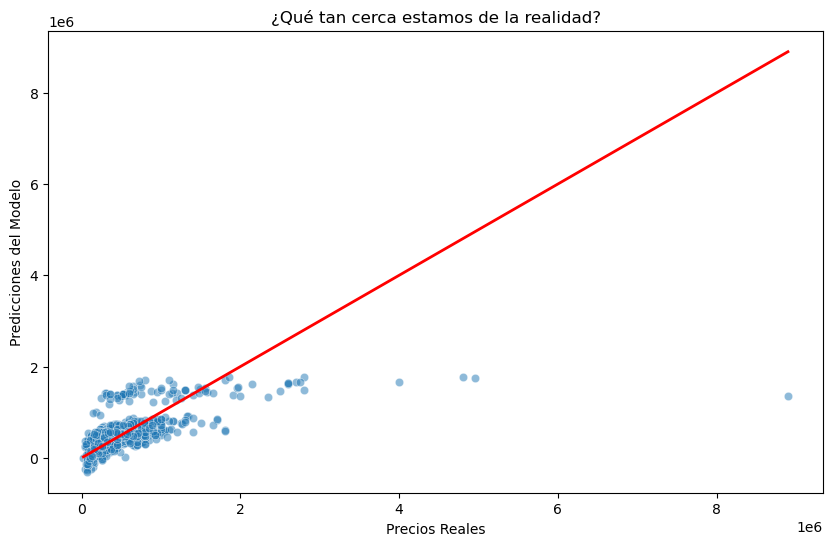

In [26]:
import seaborn as sns

# Generar predicciones
predictions = model.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Línea ideal
plt.xlabel('Precios Reales')
plt.ylabel('Predicciones del Modelo')
plt.title('¿Qué tan cerca estamos de la realidad?')
plt.show()

Mejorar el modelo

(0.0, 2000000.0)

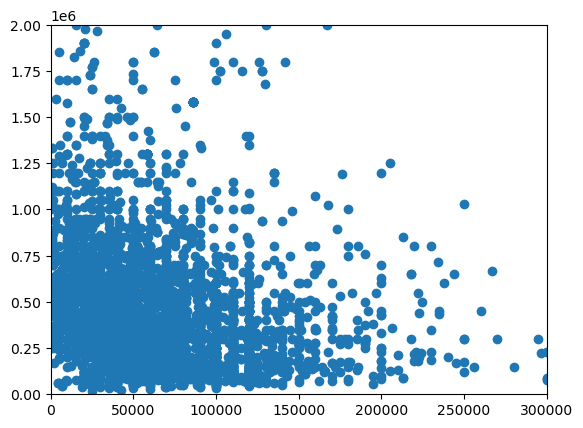

In [21]:
plt.scatter(df['km_driven'],df['selling_price'])
plt.xlim(0,300000)
plt.ylim(0,2000000)

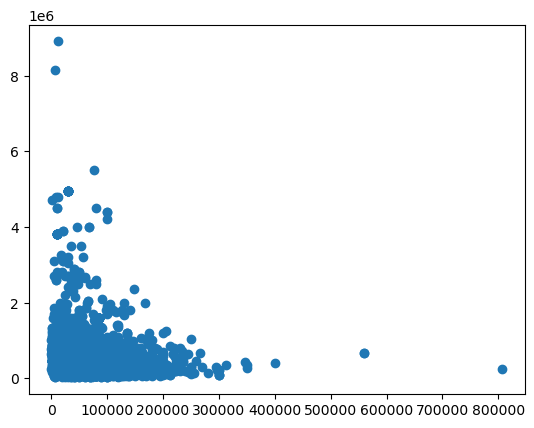

In [22]:
plt.scatter(df['km_driven'],df['selling_price'])

In [24]:
df = df[(df['selling_price'] < 2000000) & (df['km_driven'] < 300000) ]
df.head(10)

,name,year,selling_price,km_driven,seller_type,owner,Age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Manual
0,Maruti 800 AC,2007,60000,70000,Individual,First Owner,19,False,False,False,True,True
1,Maruti Wagon R LXI Minor,2007,135000,50000,Individual,First Owner,19,False,False,False,True,True
2,Hyundai Verna 1.6 SX,2012,600000,100000,Individual,First Owner,14,True,False,False,False,True
3,Datsun RediGO T Option,2017,250000,46000,Individual,First Owner,9,False,False,False,True,True
4,Honda Amaze VX i-DTEC,2014,450000,141000,Individual,Second Owner,12,True,False,False,False,True
5,Maruti Alto LX BSIII,2007,140000,125000,Individual,First Owner,19,False,False,False,True,True
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Individual,First Owner,10,False,False,False,True,True
7,Tata Indigo Grand Petrol,2014,240000,60000,Individual,Second Owner,12,False,False,False,True,True
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Individual,First Owner,11,False,False,False,True,True
9,Maruti Celerio Green VXI,2017,365000,78000,Individual,First Owner,9,False,False,False,False,True


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4226 entries, 0 to 4339
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   name                 4226 non-null   object
 1   year                 4226 non-null   int64 
 2   selling_price        4226 non-null   int64 
 3   km_driven            4226 non-null   int64 
 4   seller_type          4226 non-null   object
 5   owner                4226 non-null   object
 6   Age                  4226 non-null   int64 
 7   fuel_Diesel          4226 non-null   bool  
 8   fuel_Electric        4226 non-null   bool  
 9   fuel_LPG             4226 non-null   bool  
 10  fuel_Petrol          4226 non-null   bool  
 11  transmission_Manual  4226 non-null   bool  
dtypes: bool(5), int64(4), object(3)
memory usage: 284.8+ KB


In [31]:
X = df[['km_driven','Age']]
y = df['selling_price']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
predictions = model.predict(X_test)
mae = metrics.mean_absolute_error(y_test, predictions)

# 3. Calcular el Coeficiente de Determinación (R^2)
r2 = metrics.r2_score(y_test, predictions)

print(f"MAE: {mae}")
print(f"R-cuadrado: {r2}")

MAE: 193267.3926274329
R-cuadrado: 0.2864988340067979


In [35]:
from sklearn.ensemble import RandomForestRegressor

# 1. Definir el nuevo modelo (mucho más potente para datos sucios)
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
X = df[['km_driven','Age','fuel_Diesel',	'fuel_Electric','fuel_LPG','fuel_Petrol','transmission_Manual']]
y = df['selling_price']
# 2. Entrenar con las mismas variables que usaste antes (las 7 u 8 originales)
# Asegúrate de usar el X que tenía Age, km, Fuel, Transmission, etc.
forest_model.fit(X_train, y_train)

# 3. Predecir y Evaluar
forest_preds = forest_model.predict(X_test)
forest_mae = metrics.mean_absolute_error(y_test, forest_preds)
forest_r2 = metrics.r2_score(y_test, forest_preds)

print(f"--- RANDOM FOREST ---")
print(f"Nuevo MAE: {forest_mae}")
print(f"Nuevo R-cuadrado: {forest_r2}")

--- RANDOM FOREST ---
Nuevo MAE: 172296.76526790948
Nuevo R-cuadrado: 0.37422111703090355
